In [1]:
import io
import zipfile
import urllib.request
from pathlib import Path
import pandas as pd

# --- Params ---
participant_id = 'MW_SSH_05'
transcripts_dir = Path('transcripts')  # extracted CSVs will be placed here
transcripts_dir.mkdir(parents=True, exist_ok=True)

# --- Ensure TRANSCRIPTS.zip is downloaded & extracted ---
zip_url = 'https://zenodo.org/records/15222484/files/TRANSCRIPTS.zip?download=1'
expected_csv = transcripts_dir / f'{participant_id}.csv'

if not expected_csv.exists():
    print('Downloading TRANSCRIPTS.zip from Zenodo...')
    with urllib.request.urlopen(zip_url) as resp:
        data = resp.read()
    with zipfile.ZipFile(io.BytesIO(data)) as zf:
        zf.extractall(transcripts_dir)
    print(f'Extracted transcripts to: {transcripts_dir.resolve()}')
else:
    print('Transcripts already present, skipping download.')

# --- Load problems and responses from Zenodo ---
problems = pd.read_csv('https://zenodo.org/records/15222484/files/PROBLEMS.csv')
responses = pd.read_csv('https://zenodo.org/records/15222484/files/PROBLEMS_RESPONSES.csv')
merged_problems = pd.merge(responses, problems, on='problem_id', how='inner')

# Use column names as defined in the dataset docs
prediction_features = ['participant_decision', 'participant_certaintity', 'model_class', 'model_probability']
print(merged_problems[merged_problems['participant_id'] == participant_id][prediction_features])

# --- Retrieve transcript text for problem __P1__ for the participant ---
transcripts = pd.read_csv(expected_csv)
# Forward-fill problem markers within the participant's transcript
if 'problem_id' in transcripts.columns:
    transcripts['problem_id'] = transcripts['problem_id'].ffill()
    subset = transcripts[transcripts['problem_id'] == '__P1__']
else:
    subset = pd.DataFrame()

# Show key columns if present
cols = [c for c in ['speaker_id', 'slide_id', 'question_id', 'problem_id', 'text'] if c in subset.columns]
print(subset[cols] if cols else subset)

Transcripts already present, skipping download.
   participant_decision participant_certaintity model_class model_probability
57              trujący           średnio pewny     jadalny              0,54
58              jadalny           średnio pewny     jadalny              0,95
59              jadalny      zdecydowanie pewny     trujący                 1
    speaker_id slide_id question_id problem_id  \
180  MW_SSH_05      NaN         NaN     __P1__   
181         MW      NaN         NaN     __P1__   
182  MW_SSH_05      NaN         NaN     __P1__   

                                                  text  
180        Ok. Średnica 17,30... Mogę po całej kartce?  
181               Jasne, proszę sobie mazać spokojnie.  
182  Ok to wróćmy do… To była wysokość, średnica ka...  


In [2]:
from pathlib import Path

import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- Paths ---
DATA_PATH = Path("data/processed/participant_documents.csv")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# --- Load participant-level documents ---
docs = pd.read_csv(DATA_PATH)

print(docs.head())
print(docs.columns)
print(docs["label"].value_counts())

X = docs["full_document"].fillna("")
y = docs["label"]

# --- Cross-validation ---
cv = StratifiedKFold(
    #n_splits=5,
    n_splits=3,
    shuffle=True, #przed podziałem dane są mieszane
    random_state=42 #ziarno losowości
)

# --- TF-IDF configuration ---

polish_stopwords = [
    "i", "oraz", "a", "ale", "że", "to", "jest", "są",
    "być", "było", "była", "były",
    "ten", "ta", "te", "tym", "tego", "tej", "tych",
    "tak", "nie", "no", "mhm",
    "yyy", "yy",
    "w", "we", "z", "ze", "na", "do", "od", "po",
    "dla", "o", "u",
    "się", "sobie", "mi", "mnie", "ja",
    "pani", "pan",
    "tutaj", "tam",
    "bardziej", "raczej", "chyba", "może",
    "jakby", "więc", "czyli",
    "none", "nan",
    "przechodzę", "slajdu", "slajdzie", "slajd", "slajdy",
    "kolejnego", "kolejny", "następnego", "następny",
    "czytam", "mówi", "ns", "ok", "dobrze"
]

tfidf = TfidfVectorizer(
    lowercase=True, #zamienia tekst na małe litery
    max_features=5000, #zostawia maksymalnie 5000 najważniejszych cech
    ngram_range=(1, 2), #bierze pojedyncze słowa i pary słów
    min_df=2, #słowo musi pojawić się u co najmniej 2 uczestników
    max_df=0.8, #ignoruje słowa pojawiające się u ponad 80% osób
    stop_words=polish_stopwords #usuwa mało informacyjne słowa
)

# --- Model 1: TF-IDF + Logistic Regression ---
tfidf_logreg = Pipeline([
    ("tfidf", tfidf),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced"
    ))
])

logreg_scores = cross_val_score(
    tfidf_logreg,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("TF-IDF + Logistic Regression")
print("F1 macro scores:", logreg_scores)
print("Mean F1 macro:", logreg_scores.mean())

# --- Model 2: TF-IDF + Linear SVM ---
tfidf_svm = Pipeline([
    ("tfidf", tfidf),
    ("clf", LinearSVC(
        class_weight="balanced"
    ))
])

svm_scores = cross_val_score(
    tfidf_svm,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("\nTF-IDF + Linear SVM")
print("F1 macro scores:", svm_scores)
print("Mean F1 macro:", svm_scores.mean())

# --- Save results ---
results = pd.DataFrame({
    "model": ["TFIDF_LogisticRegression", "TFIDF_LinearSVM"],
    "f1_macro_mean": [logreg_scores.mean(), svm_scores.mean()],
    "f1_macro_std": [logreg_scores.std(), svm_scores.std()]
})

results.to_csv(RESULTS_DIR / "tfidf_results.csv", index=False)

print("\nSaved results to:", RESULTS_DIR / "tfidf_results.csv")
print(results)

  participant_id label                                      full_document  \
0       DR_IT_05    IT  [SLIDE=None] [QUESTION=None] [PROBLEM=None] , ...   
1      DR_SSH_01   SSH  [SLIDE=__S00__] [QUESTION=None] [PROBLEM=None]...   
2      DR_SSH_02   SSH  [SLIDE=__S1__] [QUESTION=None] [PROBLEM=None] ...   
3      DR_SSH_03   SSH  [SLIDE=__S1__] [QUESTION=None] [PROBLEM=None] ...   
4      DR_SSH_04   SSH  [SLIDE=None] [QUESTION=None] [PROBLEM=None] Cz...   

   n_segments  
0          34  
1          34  
2          33  
3          33  
4          37  
Index(['participant_id', 'label', 'full_document', 'n_segments'], dtype='object')
label
SSH    18
DE     13
IT      8
Name: count, dtype: int64
TF-IDF + Logistic Regression
F1 macro scores: [0.78571429 0.6        0.8042328 ]
Mean F1 macro: 0.7299823633156967

TF-IDF + Linear SVM
F1 macro scores: [0.78571429 0.53571429 0.8042328 ]
Mean F1 macro: 0.7085537918871253

Saved results to: results\tfidf_results.csv
                      model  f

In [3]:
import re
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Clean text only for interpretation ---
def clean_for_interpretation(text):
    text = str(text).lower()

    # remove context markers
    text = re.sub(r"\[slide=.*?\]", " ", text)
    text = re.sub(r"\[question=.*?\]", " ", text)
    text = re.sub(r"\[problem=.*?\]", " ", text)

    # remove IDs
    text = re.sub(r"__q\d+__", " ", text)
    text = re.sub(r"__s\d+__", " ", text)
    text = re.sub(r"__p\d+__", " ", text)

    # remove numbers
    text = re.sub(r"\d+", " ", text)

    # remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

# --- Cleaned text ---
X_clean = X.apply(clean_for_interpretation)

# --- TF-IDF for interpretation ---
tfidf_interpret = TfidfVectorizer(
    lowercase=True,
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.8,
    stop_words=polish_stopwords
)

X_tfidf_clean = tfidf_interpret.fit_transform(X_clean)

# --- Train model ---
clf_clean = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)
clf_clean.fit(X_tfidf_clean, y)

feature_names = np.array(tfidf_interpret.get_feature_names_out()) #pobiera listę słów/par słów, które TF-IDF stworzył
classes = clf_clean.classes_ #pobiera nazwy klas

# --- Top words ---
TOP_N = 20

for i, class_label in enumerate(classes):
    top_features = np.argsort(clf_clean.coef_[i])[-TOP_N:]

    print(f"\n===== TOP FEATURES FOR CLASS: {class_label} =====")

    for idx in reversed(top_features):
        print(feature_names[idx])


===== TOP FEATURES FOR CLASS: DE =====
natomiast
gatunki
gatunków
śmiech
gatunek
gatunku
oczywiście
podobnie
czasami
czy czy
sztuczna inteligencja
sztuczna
powiem
rurki
inteligencja
również
dokładnie dokładnie
momencik
wśród
zapach

===== TOP FEATURES FOR CLASS: IT =====
niewyraźne
jeżeli
faktycznie
widzimy
powiedziałabym
ai
naprawdę
za bardzo
szczerze mówiąc
zrozumieć
cichu
tys
odnośnie
tekstu
wynik
czynienia
czyta cichu
wyszło
prawdopodobieństwa
szczerze

===== TOP FEATURES FOR CLASS: SSH =====
sumie
czytelne
pewna
mniejsza
większa
jednak
gdyby
sensie
razie
także
średnio
większa niż
dodać
wrażenie
zgaduję
przypadku
brązowy
poprzednich
zmienia koloru
jestem pewna


In [4]:
from sklearn.model_selection import cross_val_predict

y_pred_logreg = cross_val_predict(
    tfidf_logreg,
    X,
    y,
    cv=cv
)

comparison_df_logreg = pd.DataFrame({
    "participant_id": docs["participant_id"],
    "true_label": y,
    "predicted_label": y_pred_logreg
})

print(comparison_df_logreg)

   participant_id true_label predicted_label
0        DR_IT_05         IT             SSH
1       DR_SSH_01        SSH             SSH
2       DR_SSH_02        SSH             SSH
3       DR_SSH_03        SSH             SSH
4       DR_SSH_04        SSH             SSH
5       DR_SSH_06        SSH             SSH
6       DR_SSH_07        SSH             SSH
7        MK_IT_03         IT             SSH
8        MK_IT_06         IT             SSH
9       MK_SSH_02        SSH             SSH
10      MK_SSH_04        SSH             SSH
11      MK_SSH_05        SSH             SSH
12      MK_SSH_07        SSH             SSH
13       MW_IT_02         IT             SSH
14       MW_IT_06         IT              IT
15       MW_IT_07         IT             SSH
16      MW_SSH_01        SSH             SSH
17      MW_SSH_03        SSH             SSH
18      MW_SSH_04        SSH             SSH
19      MW_SSH_05        SSH             SSH
20       MZ_IT_05         IT             SSH
21       M

TF-IDF pozwala dobrze odróżnić ekspertów (DE) oraz studentów SSH, natomiast grupa IT pozostaje trudna do klasyfikacji i jest często mylona z SSH. Może to sugerować podobny sposób opisywania wizualizacji oraz podobny styl językowy między tymi grupami.

**_WYNIKI Z 3 OBSERWACJI:_**

In [5]:
import pandas as pd

comparison_results = pd.DataFrame({
    "Version": [
        "5-fold + SVM",
        "3-fold + SVM",
        "3-fold + Logistic Regression"
    ],
    "IT correct": [
        "1/8",
        "2/8",
        "2/8"
    ],
    "DE correct": [
        "11/13",
        "11/13",
        "12/13"
    ],
    "SSH correct": [
        "18/18",
        "18/18",
        "18/18"
    ]
})

print(comparison_results)

                        Version IT correct DE correct SSH correct
0                  5-fold + SVM        1/8      11/13       18/18
1                  3-fold + SVM        2/8      11/13       18/18
2  3-fold + Logistic Regression        2/8      12/13       18/18


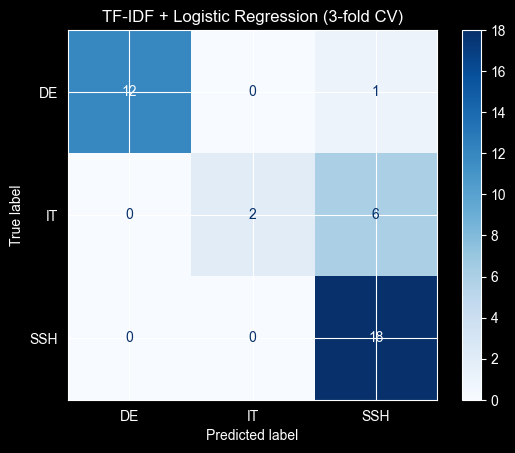

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

labels = ["DE", "IT", "SSH"]

cm = confusion_matrix(
    y,
    y_pred_logreg,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(cmap="Blues")

plt.title("TF-IDF + Logistic Regression (3-fold CV)")
plt.show()